In [1]:
# Cell 1: Upload data, clean data, split train/test

!pip -q install scikit-learn openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import files

print("TensorFlow:", tf.__version__)

# Upload CSV or Excel file
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
print("Uploaded file:", file_name)

# Read data
if file_name.endswith(".csv"):
    df = pd.read_csv(file_name)
elif file_name.endswith(".xlsx"):
    df = pd.read_excel(file_name)
else:
    raise ValueError("Unsupported file type. Please upload .csv or .xlsx")

print("Raw shape:", df.shape)

# Required columns
required_cols = [
    "ArrivalTime",
    "DecisionTime",
    "qA_Decision",
    "qB_Decision",
    "qC_Decision",
    "AssignedRoute",
    "ReworkCount",
    "TotalTimeInSystem"
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# Clean data
df = df[required_cols].copy()

for col in required_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().copy()
df = df[df["TotalTimeInSystem"] > 0].copy()
df = df[df["AssignedRoute"].isin([1, 2, 3])].copy()

print("Cleaned shape:", df.shape)

# Features and label
feature_cols = [
    "DecisionTime",
    "qA_Decision",
    "qB_Decision",
    "qC_Decision",
    "AssignedRoute"
]

label_col = "TotalTimeInSystem"

X = df[feature_cols].copy()
y = df[label_col].copy()

# Separate training and testing datasets
train_X_raw, test_X_raw, train_y, test_y = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# Manual normalization using training data only
norm_mean = train_X_raw.mean()
norm_std = train_X_raw.std().replace(0, 1)

train_X = (train_X_raw - norm_mean) / norm_std
test_X = (test_X_raw - norm_mean) / norm_std

train_X = train_X.astype(np.float32)
test_X = test_X.astype(np.float32)
train_y = train_y.astype(np.float32)
test_y = test_y.astype(np.float32)

print("Train set:", train_X.shape)
print("Test set:", test_X.shape)

print("\nNormalization mean:")
print(norm_mean)

print("\nNormalization std:")
print(norm_std)

TensorFlow: 2.20.0


Saving TrainingData.xlsx to TrainingData.xlsx
Uploaded file: TrainingData.xlsx
Raw shape: (464, 8)
Cleaned shape: (464, 8)
Train set: (371, 5)
Test set: (93, 5)

Normalization mean:
DecisionTime     11.995371
qA_Decision       0.574124
qB_Decision       0.792453
qC_Decision       0.409704
AssignedRoute     2.053908
dtype: float64

Normalization std:
DecisionTime     6.446572
qA_Decision      0.659057
qB_Decision      0.813765
qC_Decision      0.564071
AssignedRoute    0.826784
dtype: float64


Epoch 1/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 4.2142 - val_loss: 3.9580
Epoch 2/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9418 - val_loss: 3.6898
Epoch 3/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.6392 - val_loss: 3.3734
Epoch 4/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.2687 - val_loss: 2.9981
Epoch 5/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8369 - val_loss: 2.6014
Epoch 6/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3599 - val_loss: 2.1952
Epoch 7/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9171 - val_loss: 1.8295
Epoch 8/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5866 - val_loss: 1.4738
Epoch 9/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3411 - val_loss: 1.1796
Epoch 10/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1845 - val_loss: 1.0104
Epoch 11/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0855 - val_loss: 0.8684
Epoch 12/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step

===== Model 1 Results =====
Architecture: Dense(32) -> Dense(16) -> Dense(1)
Test MAE  [hours]: 0.6369025707244873
Test MAE  [minutes]: 38.21415424346924
Test RMSE [hours]: 1.512625567685859
Test R2: 0.6633080244064331


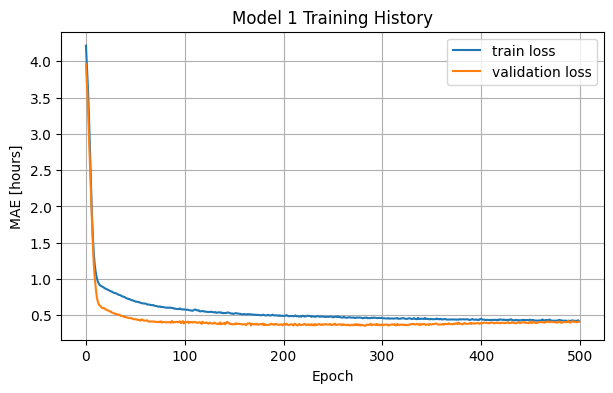

In [4]:
# Cell 2: Model 1 - Small FFNN architecture

model_1 = keras.Sequential([
    layers.Input(shape=(train_X.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mean_absolute_error"
)

history_1 = model_1.fit(
    train_X,
    train_y,
    validation_split=0.20,
    epochs=500,
    batch_size=16,
    verbose=1
)

pred_1 = model_1.predict(test_X).flatten()

mae_1 = mean_absolute_error(test_y, pred_1)
mse_1 = mean_squared_error(test_y, pred_1)
rmse_1 = np.sqrt(mse_1)
r2_1 = r2_score(test_y, pred_1)

print("\n===== Model 1 Results =====")
print("Architecture: Dense(32) -> Dense(16) -> Dense(1)")
print("Test MAE  [hours]:", mae_1)
print("Test MAE  [minutes]:", mae_1 * 60)
print("Test RMSE [hours]:", rmse_1)
print("Test R2:", r2_1)

plt.figure(figsize=(7, 4))
plt.plot(history_1.history["loss"], label="train loss")
plt.plot(history_1.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("MAE [hours]")
plt.title("Model 1 Training History")
plt.legend()
plt.grid(True)
plt.show()

Epoch 1/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 1.4795 - val_loss: 1.0887
Epoch 2/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8203 - val_loss: 0.7104
Epoch 3/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5930 - val_loss: 0.3901
Epoch 4/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4588 - val_loss: 0.2853
Epoch 5/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4200 - val_loss: 0.2563
Epoch 6/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4096 - val_loss: 0.2557
Epoch 7/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4084 - val_loss: 0.2422
Epoch 8/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3937 - val_loss: 0.2279
Epoch 9/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3860 - val_loss: 0.2134
Epoch 10/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3616 - val_loss: 0.2076
Epoch 11/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3647 - val_loss: 0.2021
Epoch 12/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

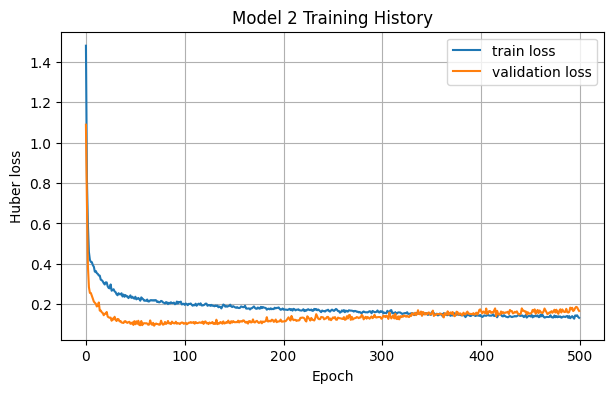


===== Architecture Comparison =====
     Model                                 Architecture  Test_MAE_hours  \
0  Model 1                            32-16-1, MAE loss        0.636903   
1  Model 2  Residual 64-64 + Dropout + 32-1, Huber loss        0.743894   

   Test_MAE_minutes  Test_RMSE_hours   Test_R2  
0         38.214154         1.512626  0.663308  
1         44.633642         1.618009  0.614760  

Best model selected for ONNX export: Model 1
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
# Cell 3: Model 2 - Residual FFNN architecture


inputs = keras.Input(shape=(train_X.shape[1],))

x1 = layers.Dense(64, activation="relu")(inputs)
x2 = layers.Dense(64, activation="relu")(x1)

# Residual connection
x = layers.Add()([x1, x2])

# Regularization
x = layers.Dropout(0.10)(x)

x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1)(x)

model_2 = keras.Model(inputs=inputs, outputs=outputs)

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(delta=0.5)
)

history_2 = model_2.fit(
    train_X,
    train_y,
    validation_split=0.20,
    epochs=500,
    batch_size=16,
    verbose=1
)

pred_2 = model_2.predict(test_X).flatten()

mae_2 = mean_absolute_error(test_y, pred_2)
mse_2 = mean_squared_error(test_y, pred_2)
rmse_2 = np.sqrt(mse_2)
r2_2 = r2_score(test_y, pred_2)

print("\n===== Model 2 Results =====")
print("Architecture: Residual FFNN: Dense(64) -> Dense(64) + Residual -> Dropout(0.10) -> Dense(32) -> Dense(1)")
print("Training loss: Huber(delta=0.5)")
print("Test MAE  [hours]:", mae_2)
print("Test MAE  [minutes]:", mae_2 * 60)
print("Test RMSE [hours]:", rmse_2)
print("Test R2:", r2_2)

plt.figure(figsize=(7, 4))
plt.plot(history_2.history["loss"], label="train loss")
plt.plot(history_2.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Huber loss")
plt.title("Model 2 Training History")
plt.legend()
plt.grid(True)
plt.show()

# Compare both architectures
comparison = pd.DataFrame({
    "Model": ["Model 1", "Model 2"],
    "Architecture": [
        "32-16-1, MAE loss",
        "Residual 64-64 + Dropout + 32-1, Huber loss"
    ],
    "Test_MAE_hours": [mae_1, mae_2],
    "Test_MAE_minutes": [mae_1 * 60, mae_2 * 60],
    "Test_RMSE_hours": [rmse_1, rmse_2],
    "Test_R2": [r2_1, r2_2]
})

print("\n===== Architecture Comparison =====")
print(comparison)

if mae_1 <= mae_2:
    best_model = model_1
    best_model_name = "Model 1"
else:
    best_model = model_2
    best_model_name = "Model 2"

print("\nBest model selected for ONNX export:", best_model_name)

best_pred = best_model.predict(test_X).flatten()

prediction_results = test_X_raw.copy()
prediction_results["Actual_TotalTimeInSystem"] = test_y.values
prediction_results["Predicted_TotalTimeInSystem"] = best_pred
prediction_results["Error"] = prediction_results["Predicted_TotalTimeInSystem"] - prediction_results["Actual_TotalTimeInSystem"]

prediction_results.to_csv("prediction_results.csv", index=False)
files.download("prediction_results.csv")

TensorFlow: 2.19.0


Saving TrainingData.xlsx to TrainingData (2).xlsx
Raw shape: (464, 8)
Cleaned shape: (464, 8)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.4334 - val_loss: 2.6584
Epoch 2/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1941 - val_loss: 1.5709
Epoch 3/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3552 - val_loss: 1.1293
Epoch 4/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1479 - val_loss: 0.8472
Epoch 5/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0171 - val_loss: 0.7184
Epoch 6/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9907 - val_loss: 0.6825
Epoch 7/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9727 - val_loss: 0.6660
Epoch 8/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9573 - val_loss: 0.6649
Epoch 9/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9468 - val_loss: 0.6460
Epoch 10/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9256 - val_loss: 0.6309
Epoch 11/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9180 - val_loss: 0.6170
Epoch 12/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

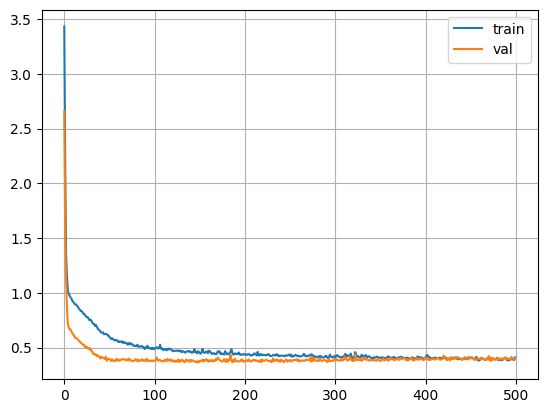

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Recommended route: 1
   Route  Predicted_TIS
0      1       3.946844
1      2       4.418157
2      3       5.174900


In [4]:
# =========================================
# Cell 4: Export best model to ONNX
# =========================================

!pip -q install tf2onnx onnx

import tf2onnx
import onnx
import tensorflow as tf
from google.colab import files

input_dim = train_X.shape[1]

@tf.function(input_signature=[tf.TensorSpec([None, input_dim], tf.float32, name="input")])
def model_fn(x):
    return best_model(x)

onnx_model, _ = tf2onnx.convert.from_function(
    model_fn,
    input_signature=[tf.TensorSpec([None, input_dim], tf.float32, name="input")],
    opset=13
)

onnx_path = "warehouse_nn_best_model.onnx"
onnx.save(onnx_model, onnx_path)

files.download(onnx_path)

print("ONNX export successful:", onnx_path)
print("Exported model:", best_model_name)
print("Input feature order:", feature_cols)
print("\nImportant: ONNX input must be normalized using the training mean and std printed in Cell 1.")